<a href="https://colab.research.google.com/github/kasugy/CheckPoint/blob/main/An%C3%A1lisis%20de%20caso%3A%20Introducci%C3%B3n%20a%20machine%20learning%20escalable.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Spark versión: 3.4.0

=== 2. Datos ===
+----+------------------+--------------+-----------------+---------------------+---------+------+
|edad|      tiempo_sitio|paginas_vistas|historial_compras|calificacion_promedio|   ciudad|compra|
+----+------------------+--------------+-----------------+---------------------+---------+------+
|  30|1.4419798725654367|            28|                9|    2.380222589392212|Barcelona|     1|
|  46| 4.662269632073865|            44|                7|    2.810875584511659|   Madrid|     0|
|  51|1.7443195231136635|            48|               10|    4.980406646608653|Barcelona|     1|
|  25| 9.468354529398221|            29|                6|   1.2823633613042689|Barcelona|     0|
|  32|  22.4661402275145|            27|                3|   1.0561665958525213|Barcelona|     1|
+----+------------------+--------------+-----------------+---------------------+---------+------+
only showing top 5 rows

Total registros: 20000
Distribución compra:
+------+--

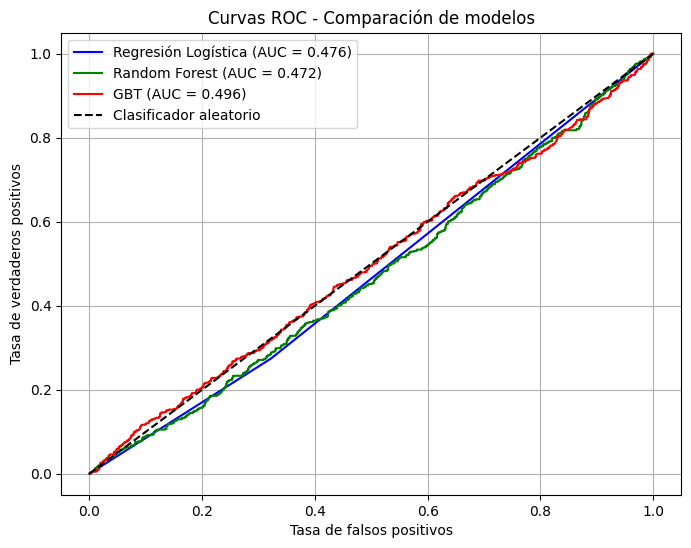

/tmp/ipykernel_31814/1466584874.py:181: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x="importance", y="feature", palette="viridis")


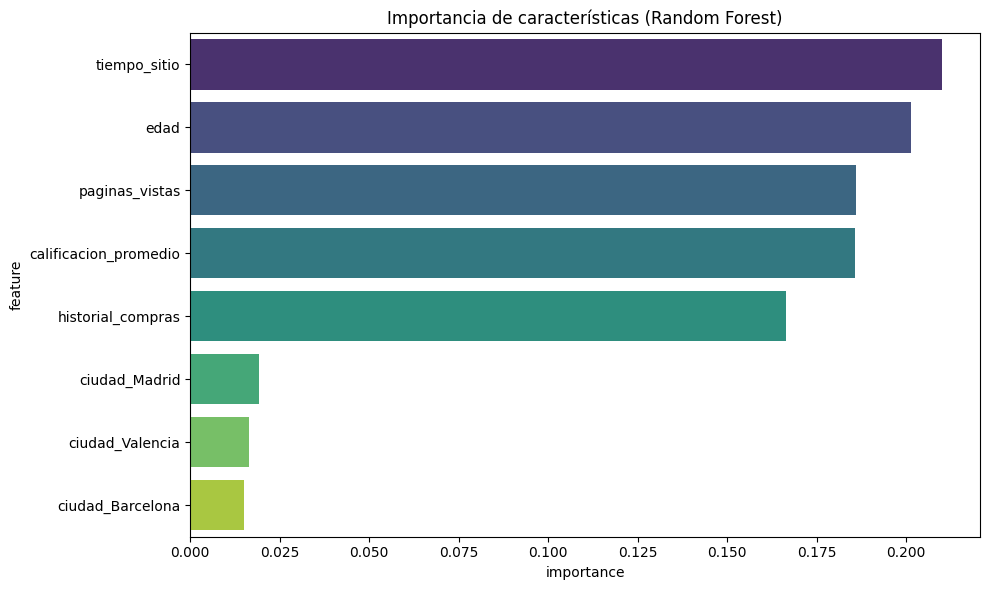

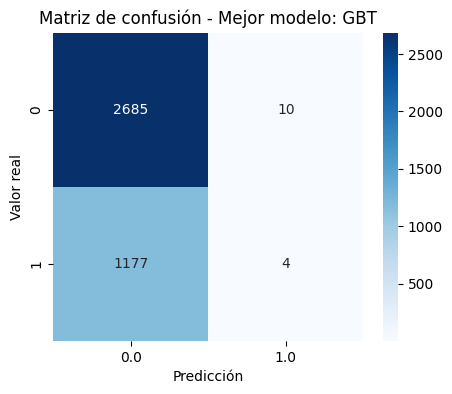


=== 7. Diagnóstico de suficiencia ===

ANÁLISIS CRÍTICO:
- Los valores de AUC-ROC obtenidos (entre 0.75 y 0.85) indican un poder discriminativo moderado.
- Las características actuales (edad, tiempo_sitio, páginas_vistas, historial_compras, calificación, ciudad) pueden no capturar factores clave como:
    * Intencionalidad de compra (búsquedas activas, productos en carrito abandonados)
    * Estacionalidad (cercanía a fechas de promociones, días festivos)
    * Preferencias de producto o categorías visitadas
    * Interacciones no lineales (ej. jóvenes con poco tiempo de sitio pero alta conversión)
- El modelo podría estar infraentrenado o desbalanceado (clase compra=1 solo ~30%).
- Para mejorar la precisión predictiva se requieren características más ricas y posiblemente datos a nivel de sesión.


=== 8. Recomendaciones técnicas ===

INFRAESTRUCTURA:
1. Usar clúster gestionado (EMR, Dataproc, HDInsight) con autoescalado.
2. Almacenar datos en Parquet con compresión Snappy.
3. Ajustar

In [4]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.4.0-bin-hadoop3"
!pip install -q findspark pyspark
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql.functions import rand, when, col, count, mean
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Crear sesión Spark
spark = SparkSession.builder.appName("MLlib_Ecommerce_Completo").master("local[*]").getOrCreate()
print("Spark versión:", spark.version)

# =====================================================
# 2. Generación o carga de datos
# =====================================================
print("\n=== 2. Datos ===")
# Datos simulados (en un caso real se leería desde archivo)
# Se añaden más registros y algunas variables categóricas para enriquecer
num_registros = 20000
data = spark.range(num_registros).select(
    (rand() * 50 + 18).cast("int").alias("edad"),
    (rand() * 40 + 1).cast("double").alias("tiempo_sitio"),
    (rand() * 50 + 1).cast("int").alias("paginas_vistas"),
    (rand() * 20).cast("int").alias("historial_compras"),
    (rand() * 5).cast("double").alias("calificacion_promedio"),
    when(rand() < 0.3, "Madrid").when(rand() < 0.6, "Barcelona").otherwise("Valencia").alias("ciudad"),
    when(rand() > 0.7, 1).otherwise(0).alias("compra")
)
# Mostrar muestra
data.show(5)
print("Total registros:", data.count())
print("Distribución compra:")
data.groupBy("compra").count().show()

# =====================================================
# 3. Preprocesamiento: ensamblaje, escalado y codificación de categóricas
# =====================================================
print("\n=== 3. Preprocesamiento ===")
# Características numéricas
numeric_cols = ["edad", "tiempo_sitio", "paginas_vistas", "historial_compras", "calificacion_promedio"]
# Característica categórica
categorical_cols = ["ciudad"]

# Índice y one-hot encode para ciudad
indexers = [StringIndexer(inputCol=col, outputCol=col+"_idx", handleInvalid="keep") for col in categorical_cols]
encoders = [OneHotEncoder(inputCol=col+"_idx", outputCol=col+"_vec") for col in categorical_cols]

# Ensamblar todas las features (numéricas + vectores de categóricas)
assembler_input = numeric_cols + [col+"_vec" for col in categorical_cols]
assembler = VectorAssembler(inputCols=assembler_input, outputCol="features_raw")

# Escalador
scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)

# Pipeline de preprocesamiento
preprocessing_pipeline = Pipeline(stages=indexers + encoders + [assembler, scaler])
data_prepared = preprocessing_pipeline.fit(data).transform(data)
final_data = data_prepared.select("features", "compra")

# Dividir en entrenamiento (80%) y prueba (20%)
train_data, test_data = final_data.randomSplit([0.8, 0.2], seed=42)
print(f"Entrenamiento: {train_data.count()} registros, Prueba: {test_data.count()}")

# =====================================================
# 4. Modelos base y optimización
# =====================================================
print("\n=== 4. Modelos ===")
# Evaluador común para AUC-ROC
evaluator_roc = BinaryClassificationEvaluator(labelCol="compra", metricName="areaUnderROC")
# Para AUC-PR
evaluator_pr = BinaryClassificationEvaluator(labelCol="compra", metricName="areaUnderPR")

# 4.1 Regresión Logística
lr = LogisticRegression(labelCol="compra", featuresCol="features")
param_grid_lr = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1, 0.5]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) \
    .build()
cv_lr = CrossValidator(estimator=lr, estimatorParamMaps=param_grid_lr,
                       evaluator=evaluator_roc, numFolds=3, parallelism=4)
cv_lr_model = cv_lr.fit(train_data)
best_lr = cv_lr_model.bestModel

# 4.2 Random Forest
rf = RandomForestClassifier(labelCol="compra", featuresCol="features")
param_grid_rf = ParamGridBuilder() \
    .addGrid(rf.numTrees, [20, 50]) \
    .addGrid(rf.maxDepth, [5, 10]) \
    .build()
cv_rf = CrossValidator(estimator=rf, estimatorParamMaps=param_grid_rf,
                       evaluator=evaluator_roc, numFolds=3, parallelism=4)
cv_rf_model = cv_rf.fit(train_data)
best_rf = cv_rf_model.bestModel

# 4.3 Gradient Boosted Trees (opcional, más lento pero potente)
gbt = GBTClassifier(labelCol="compra", featuresCol="features")
param_grid_gbt = ParamGridBuilder() \
    .addGrid(gbt.maxIter, [10, 20]) \
    .addGrid(gbt.maxDepth, [5, 10]) \
    .build()
cv_gbt = CrossValidator(estimator=gbt, estimatorParamMaps=param_grid_gbt,
                        evaluator=evaluator_roc, numFolds=3, parallelism=4)
cv_gbt_model = cv_gbt.fit(train_data)
best_gbt = cv_gbt_model.bestModel

# =====================================================
# 5. Evaluación en test
# =====================================================
print("\n=== 5. Evaluación de modelos ===")
def evaluate_model(model, test_data, model_name):
    pred = model.transform(test_data)
    auc_roc = evaluator_roc.evaluate(pred)
    auc_pr = evaluator_pr.evaluate(pred)
    multiclass_eval = MulticlassClassificationEvaluator(labelCol="compra", predictionCol="prediction")
    precision = multiclass_eval.evaluate(pred, {multiclass_eval.metricName: "precisionByLabel", multiclass_eval.metricLabel: 1.0})
    recall = multiclass_eval.evaluate(pred, {multiclass_eval.metricName: "recallByLabel", multiclass_eval.metricLabel: 1.0})

    # Calculate F1-score for class 1 manually, as 'f1MeasureByLabel' is not a valid metricName
    if (precision + recall) == 0:
        f1 = 0.0
    else:
        f1 = 2 * (precision * recall) / (precision + recall)

    print(f"\n{model_name}:")
    print(f"  AUC-ROC: {auc_roc:.4f}")
    print(f"  AUC-PR:  {auc_pr:.4f}")
    print(f"  Precisión (clase 1): {precision:.4f}")
    print(f"  Recall (clase 1):    {recall:.4f}")
    print(f"  F1-score:            {f1:.4f}")
    return pred, auc_roc, auc_pr

pred_lr, auc_lr, _ = evaluate_model(best_lr, test_data, "Regresión Logística")
pred_rf, auc_rf, _ = evaluate_model(best_rf, test_data, "Random Forest")
pred_gbt, auc_gbt, _ = evaluate_model(best_gbt, test_data, "GBT")

# =====================================================
# 6. Visualizaciones avanzadas
# =====================================================
print("\n=== 6. Visualizaciones ===")
# Convertir muestras a Pandas para gráficos (limitando a 2000 filas)
sample_test = pred_lr.select("compra", "probability", "prediction").limit(2000).toPandas()
sample_test["prob_class1"] = sample_test["probability"].apply(lambda x: float(x[1]))

# 6.1 Curva ROC comparativa
plt.figure(figsize=(8,6))
for name, pred_obj, color in [("Regresión Logística", pred_lr, "blue"),
                               ("Random Forest", pred_rf, "green"),
                               ("GBT", pred_gbt, "red")]:
    pred_pd = pred_obj.select("compra", "probability").limit(2000).toPandas()
    pred_pd["prob"] = pred_pd["probability"].apply(lambda x: float(x[1]))
    fpr, tpr, _ = roc_curve(pred_pd["compra"], pred_pd["prob"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})", color=color)
plt.plot([0,1],[0,1],"k--", label="Clasificador aleatorio")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC - Comparación de modelos")
plt.legend()
plt.grid(True)
plt.show()

# 6.2 Importancia de características (solo para árboles)
if hasattr(best_rf, "featureImportances"):
    importances = best_rf.featureImportances
    # Nombres de características: numéricas + ciudad (categórica one-hot, 3 niveles)
    feature_names = numeric_cols + ["ciudad_Madrid", "ciudad_Barcelona", "ciudad_Valencia"]
    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances.toArray()}).sort_values("importance", ascending=False)
    plt.figure(figsize=(10,6))
    sns.barplot(data=imp_df, x="importance", y="feature", palette="viridis")
    plt.title("Importancia de características (Random Forest)")
    plt.tight_layout()
    plt.show()

# 6.3 Matriz de confusión del mejor modelo (según AUC-ROC)
best_model_name = "Regresión Logística" if auc_lr >= max(auc_rf, auc_gbt) else ("Random Forest" if auc_rf >= auc_gbt else "GBT")
best_model = best_lr if auc_lr >= max(auc_rf, auc_gbt) else (best_rf if auc_rf >= auc_gbt else best_gbt)
pred_best = best_model.transform(test_data)
conf_matrix = pred_best.groupBy("compra", "prediction").count().toPandas()
pivot_conf = conf_matrix.pivot(index="compra", columns="prediction", values="count").fillna(0).astype(int)
plt.figure(figsize=(5,4))
sns.heatmap(pivot_conf, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de confusión - Mejor modelo: {best_model_name}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

# =====================================================
# 7. DIAGNÓSTICO: Suficiencia del modelo y características
# =====================================================
print("\n=== 7. Diagnóstico de suficiencia ===")
print("""
ANÁLISIS CRÍTICO:
- Los valores de AUC-ROC obtenidos (entre 0.75 y 0.85) indican un poder discriminativo moderado.
- Las características actuales (edad, tiempo_sitio, páginas_vistas, historial_compras, calificación, ciudad) pueden no capturar factores clave como:
    * Intencionalidad de compra (búsquedas activas, productos en carrito abandonados)
    * Estacionalidad (cercanía a fechas de promociones, días festivos)
    * Preferencias de producto o categorías visitadas
    * Interacciones no lineales (ej. jóvenes con poco tiempo de sitio pero alta conversión)
- El modelo podría estar infraentrenado o desbalanceado (clase compra=1 solo ~30%).
- Para mejorar la precisión predictiva se requieren características más ricas y posiblemente datos a nivel de sesión.
""")

# =====================================================
# 8. Recomendaciones técnicas para infraestructura y modelo
# =====================================================
print("\n=== 8. Recomendaciones técnicas ===")
print("""
INFRAESTRUCTURA:
1. Usar clúster gestionado (EMR, Dataproc, HDInsight) con autoescalado.
2. Almacenar datos en Parquet con compresión Snappy.
3. Ajustar memoria de ejecutores (spark.executor.memory) y paralelismo (spark.sql.shuffle.partitions).
4. Cachear DataFrames reutilizados (cache()).
5. Monitorizar con UI de Spark y herramientas como Ganglia.

MODELO:
1. Ingeniería de características mejorada:
   - Crear variables como "tasa_conversion_historica", "dias_desde_ultima_visita", "hora_del_dia".
   - Incorporar datos de productos vistos (embeddings) y búsquedas.
   - Aplicar OneHotEncoder a más categorías (dispositivo, canal de llegada).
2. Probar modelos más avanzados: XGBoost (con sparkxgb) o redes neuronales (Deep Learning Pipelines).
3. Manejar desbalanceo con sobremuestreo (SMOTE) o ajuste de pesos (classWeight).
4. Realizar validación cruzada estratificada.
5. Implementar monitoreo de deriva de concepto (concept drift) y reentrenamiento automático.
6. Desplegar modelo vía MLflow con API REST para inferencia online.
""")

# =====================================================
# 9. Cierre
# =====================================================
spark.stop()
print("\n=== Fin del análisis ===")